# 02 - Exploratory Data Analysis

This module explores the raw dataset before any cleaning: averages and ranges, a correlation heatmap, and a couple of charts, to build intuition about the data before we model it.

**Input:** `../01-data-collection/data/Loan_default.csv`
**Output:** `output/correlation_heatmap.png`, `output/exploration_charts.png`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../01-data-collection/data/Loan_default.csv"
TARGET = "Default"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")


Loaded 255,347 rows, 18 columns


In [2]:
desc = df.describe().T[["mean", "std", "min", "50%", "max"]]
desc.columns = ["average", "spread (std dev)", "min", "middle (median)", "max"]
print(desc.round(2).to_string())


                  average  spread (std dev)      min  middle (median)       max
Age                 43.50             14.99     18.0            43.00      69.0
Income           82499.30          38963.01  15000.0         82466.00  149999.0
LoanAmount      127578.87          70840.71   5000.0        127556.00  249999.0
CreditScore        574.26            158.90    300.0           574.00     849.0
MonthsEmployed      59.54             34.64      0.0            60.00     119.0
NumCreditLines       2.50              1.12      1.0             2.00       4.0
InterestRate        13.49              6.64      2.0            13.46      25.0
LoanTerm            36.03             16.97     12.0            36.00      60.0
DTIRatio             0.50              0.23      0.1             0.50       0.9
Default              0.12              0.32      0.0             0.00       1.0


**How to read this:** look at the **min** and **max** columns — notice how different the scales are. `Age` runs 18-69, but `Income` runs into the hundreds of thousands, and `DTIRatio` only runs 0.1-0.9. Before feeding these numbers into a model (Module 4/5), we'll rescale them to a common scale — otherwise a model would think `Income` matters more than `Age` simply because its numbers are bigger.

Saved: output/correlation_heatmap.png


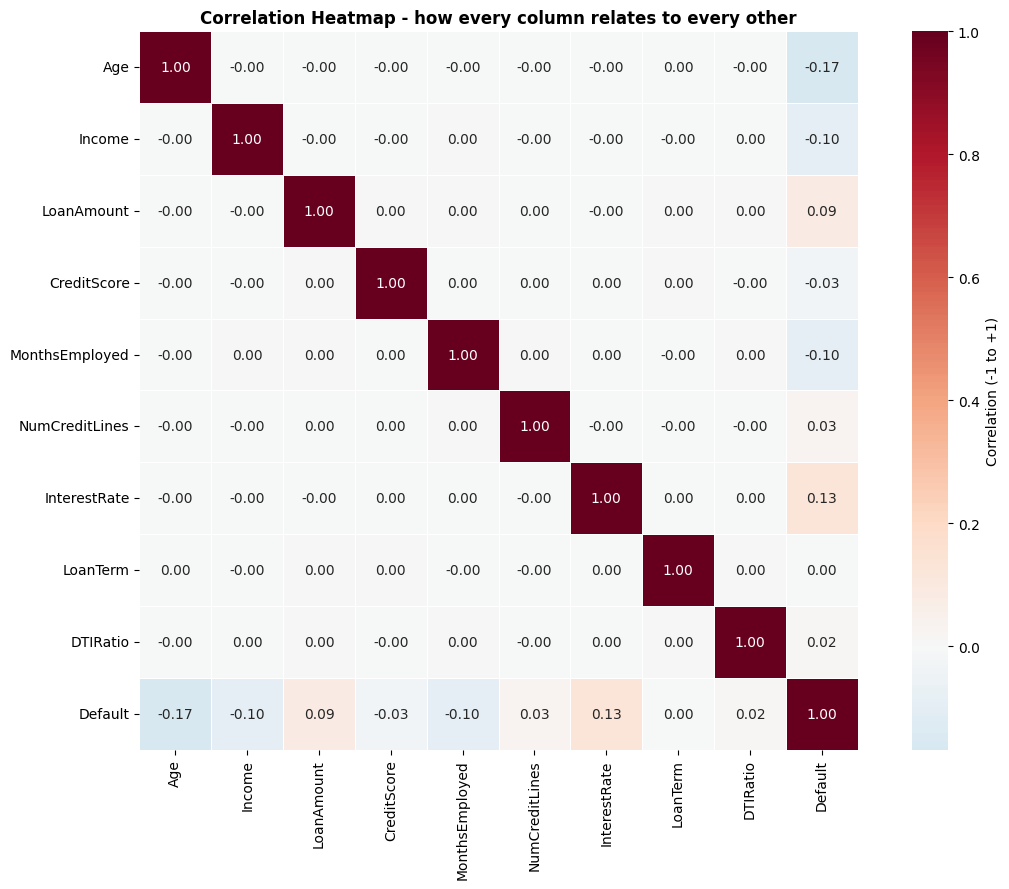


Columns most related to Default (ignoring sign, strongest first):
Age              -0.168
InterestRate      0.131
Income           -0.099
MonthsEmployed   -0.097
LoanAmount        0.087
CreditScore      -0.034
NumCreditLines    0.028
DTIRatio          0.019
LoanTerm          0.001
Name: Default, dtype: float64


In [3]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Correlation (-1 to +1)"},
)
plt.title("Correlation Heatmap - how every column relates to every other", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"), dpi=140, bbox_inches="tight")
print("Saved: output/correlation_heatmap.png")
plt.show()

print("\nColumns most related to Default (ignoring sign, strongest first):")
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(target_corr.round(3))


**How to read the heatmap:**

- Look at the `Default` row/column — that shows how every other column relates to the thing we want to predict.
- The `Default` row is mostly pale — every individual column only weakly relates to default. The strongest is `Age` (around -0.17) — older borrowers default slightly less. `InterestRate` is the strongest positive one (around +0.13).
- This is expected, not a failure — no single fact perfectly predicts default. Module 5 combines many weak clues together into one useful prediction.
- No two predictor columns look almost perfectly matched with each other either, which means the model won't get confused by two columns saying the same thing twice.

Saved: output/exploration_charts.png


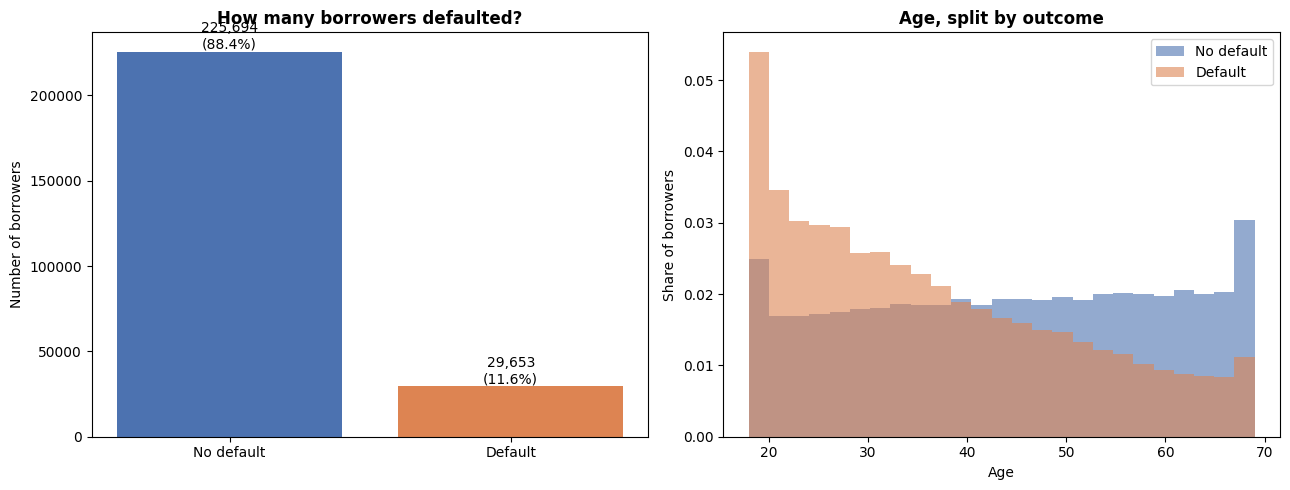

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df[TARGET].value_counts().sort_index()
axes[0].bar(["No default", "Default"], counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom")
axes[0].set_title("How many borrowers defaulted?", fontweight="bold")
axes[0].set_ylabel("Number of borrowers")

for cls, colour, label in [(0, "#4C72B0", "No default"), (1, "#DD8452", "Default")]:
    axes[1].hist(df.loc[df[TARGET] == cls, "Age"], bins=25, alpha=0.6,
                 density=True, color=colour, label=label)
axes[1].set_title("Age, split by outcome", fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Share of borrowers")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exploration_charts.png"), dpi=140, bbox_inches="tight")
print("Saved: output/exploration_charts.png")
plt.show()


## How to read this

- **Left chart** — confirms the 88.4% / 11.6% split visually.
- **Right chart** — the two age curves overlap a lot, but the "Default" curve leans slightly younger. That's what a weak correlation of -0.17 actually looks like: real, but not strong enough on its own.

## Next module
Module 3 (Data Preprocessing) cleans this raw data: checks duplicates, checks for "cheating" columns, and drops the useless ID column.
